<a href="https://colab.research.google.com/github/Hirakhan15/PCOs/blob/main/resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

ROOT_DIR = '/content/drive/MyDrive/PCOS'
number_of_images = {}

for dir in os.listdir(ROOT_DIR):
   number_of_images[dir] = len(os.listdir(os.path.join(ROOT_DIR,dir)))
   print("",dir,"" ,number_of_images[dir])

 noninfected  5000
 infected  5000


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split

data = []
for category in ['infected', 'noninfected']:
    folder_path = os.path.join(ROOT_DIR, category)
    for img in os.listdir(folder_path):
        data.append({'filepath': os.path.join(folder_path, img), 'label': category})

df = pd.DataFrame(data)

# Splitting 70/15/15
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # This now uses ResNet logic
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Only Preprocessing for Val/Test
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

val_gen = test_datagen.flow_from_dataframe(
    val_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary'
)

Found 7000 validated image filenames belonging to 2 classes.
Found 1500 validated image filenames belonging to 2 classes.


In [9]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load ResNet50 base
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Keep the base frozen for Transfer Learning

# The rest of your 'head' can stay the same
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('pcos_mobilenet.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25, # Adjusted based on typical PCOS convergence
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8214 - loss: 0.3966 

219/219 ━━━━━━━━━━━━━━━━━━━━ 2848s 13s/step - accuracy: 0.8217 - loss: 0.3960 - val_accuracy: 0.8973 - val_loss: 0.1768
Epoch 2/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.9422 - loss: 0.1422

219/219 ━━━━━━━━━━━━━━━━━━━━ 1824s 8s/step - accuracy: 0.9422 - loss: 0.1421 - val_accuracy: 0.9840 - val_loss: 0.0649
Epoch 3/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1777s 8s/step - accuracy: 0.9575 - loss: 0.1109 - val_accuracy: 0.9547 - val_loss: 0.1049
Epoch 4/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1777s 8s/step - accuracy: 0.9742 - loss: 0.0783 - val_accuracy: 0.9667 - val_loss: 0.0826
Epoch 5/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1764s 8s/step - accuracy: 0.9764 - loss: 0.0689 - val_accuracy: 0.9493 - val_loss: 0.1134
Epoch 6/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1783s 8s/step - accuracy: 0.9781 - loss: 0.0603 - val_accuracy: 0.9660 - val_loss: 0.0840
Epoch 7/25
219/219 ━━━━━━━━━━━━━━━━━━━━ 1761s 8s/step - accuracy: 0.9818 - loss: 0.0532 - val_accuracy: 0.9660 - val_loss: 0.0833


In [11]:
test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='filepath', y_col='label',
    target_size=(224, 224), batch_size=32, class_mode='binary', shuffle=False
)

loss, accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {accuracy*100:.2f}%")

Found 1500 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 538s 12s/step - accuracy: 0.9841 - loss: 0.0626
Final Test Accuracy: 98.40%


47/47 ━━━━━━━━━━━━━━━━━━━━ 298s 6s/step


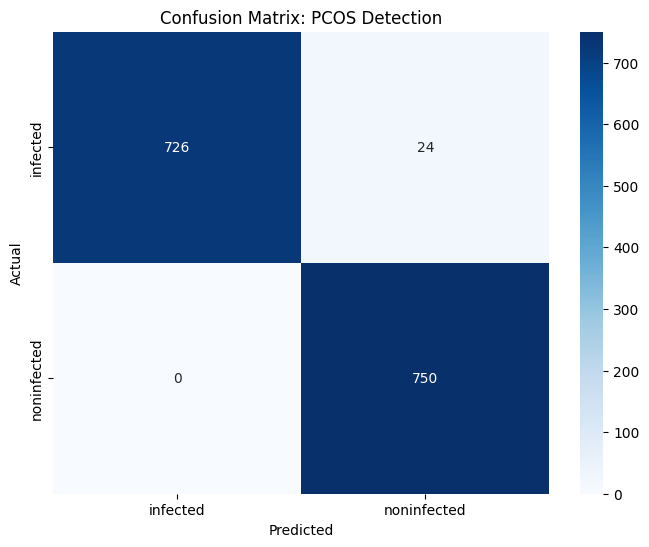


Classification Report:
              precision    recall  f1-score   support

    infected       1.00      0.97      0.98       750
 noninfected       0.97      1.00      0.98       750

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get predictions from the test set
# Important: shuffle=False in test_gen ensures labels match predictions
test_gen.reset()
predictions = model.predict(test_gen)
pred_labels = (predictions > 0.5).astype(int) # Convert probabilities to 0 or 1

# 2. Get true labels
true_labels = test_gen.classes
class_names = list(test_gen.class_indices.keys())

# 3. Create Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: PCOS Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# 4. Detailed Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

In [13]:
# Assuming 'cm' is your confusion matrix from the previous step
# In a binary classification (0=Healthy, 1=Infected):
# cm[0,0] = TN, cm[0,1] = FP
# cm[1,0] = FN, cm[1,1] = TP

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives (Healthy correctly identified): {tn}")
print(f"False Positives (Healthy misidentified as PCOS): {fp}")
print(f"False Negatives (PCOS missed by model): {fn}")
print(f"True Positives (PCOS correctly identified): {tp}")

True Negatives (Healthy correctly identified): 726
False Positives (Healthy misidentified as PCOS): 24
False Negatives (PCOS missed by model): 0
True Positives (PCOS correctly identified): 750
